# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [4]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [5]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

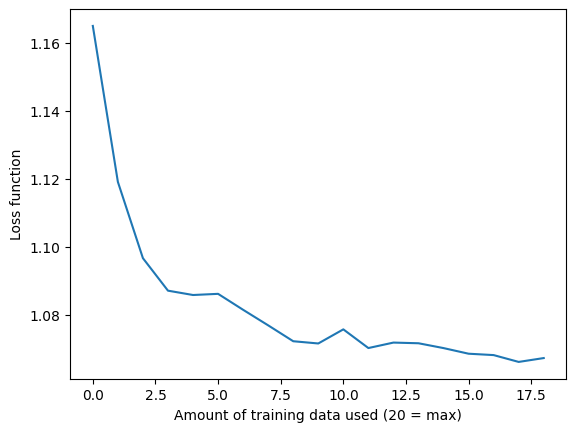

In [6]:
    plt.plot(rmse_lst)
    plt.xlabel("Amount of training data used (20 = max)")
    plt.ylabel("Loss function")

In [7]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

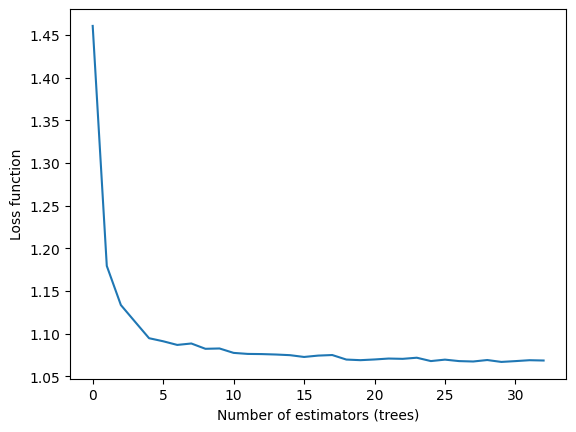

In [8]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

Credit dataset shape: (284807, 31)
Bank/AML dataset shape: (100, 6)

=== Baseline Random Forest (Credit Card Fraud) ===
Accuracy: 0.9995
Precision: 0.9573
Recall: 0.7568
F1 Score: 0.8453
ROC AUC: 0.9307


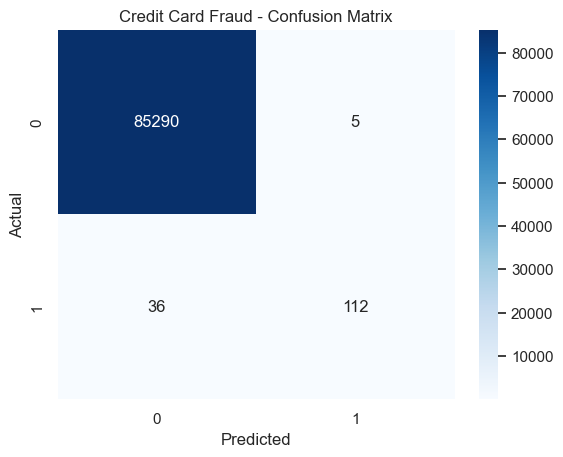


=== Tuned Random Forest (Credit Card Fraud) ===
Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
F1 Score: 0.8528
ROC AUC: 0.968

Detected anomalies: 5 / 98 records (5.10%)


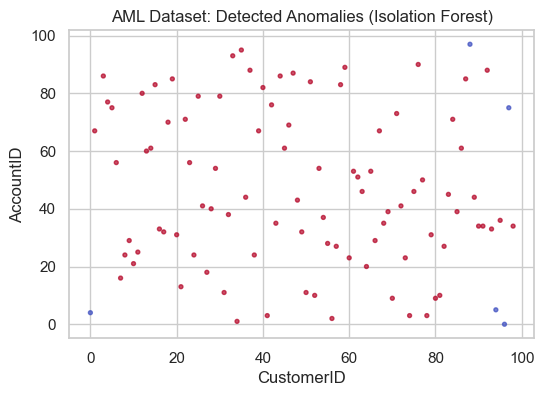

In [9]:
### Week 11 — Modeling with Two Selected Datasets
# Datasets: Credit Card Fraud (supervised) and Bank/AML (unsupervised)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score)
sns.set_theme(style="whitegrid")

# 1. Load and prepare datasets
# Update the file paths below to where your CSV files are located
credit_df = pd.read_csv("creditcard_final.csv")
aml_df = pd.read_csv("bank_customers.csv")

print("Credit dataset shape:", credit_df.shape)
print("Bank/AML dataset shape:", aml_df.shape)

# Quick cleaning
credit_df = credit_df.dropna()
aml_df = aml_df.dropna()


# 2. SUPERVISED: CREDIT CARD FRAUD MODEL

# Verify the target column
if "Class" not in credit_df.columns:
    raise ValueError("The credit card dataset must contain a column named 'Class' (0=normal, 1=fraud).")

X = credit_df.drop("Class", axis=1)
y = credit_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Baseline Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n=== Baseline Random Forest (Credit Card Fraud) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Credit Card Fraud - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Hyperparameter tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    rf, param_grid, cv=3, scoring="roc_auc", n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("\n=== Tuned Random Forest (Credit Card Fraud) ===")
print("Best Parameters:", grid_search.best_params_)
print("F1 Score:", round(f1_score(y_test, y_pred_best), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_best), 4))


# 3. UNSUPERVISED: BANK / AML ANOMALY DETECTION

aml_numeric = aml_df.select_dtypes(include=[np.number]).copy()
if aml_numeric.empty:
    raise ValueError("The AML dataset must have numeric columns for anomaly detection.")

# Isolation Forest for unsupervised anomaly detection
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
aml_df["anomaly_score"] = iso.fit_predict(aml_numeric)

# -1 = anomaly, 1 = normal
anomalies = aml_df[aml_df["anomaly_score"] == -1]
print(f"\nDetected anomalies: {len(anomalies)} / {len(aml_df)} records "
      f"({len(anomalies)/len(aml_df)*100:.2f}%)")

# Scatterplot of first two features colored by anomaly flag
num_cols = aml_numeric.columns[:2]
plt.figure(figsize=(6,4))
plt.scatter(aml_df[num_cols[0]], aml_df[num_cols[1]],
            c=aml_df["anomaly_score"], cmap="coolwarm", s=8, alpha=0.7)
plt.title("AML Dataset: Detected Anomalies (Isolation Forest)")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.show()


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

<Figure size 640x480 with 0 Axes>

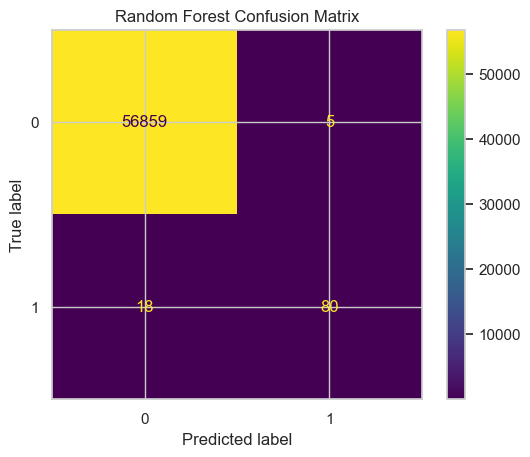

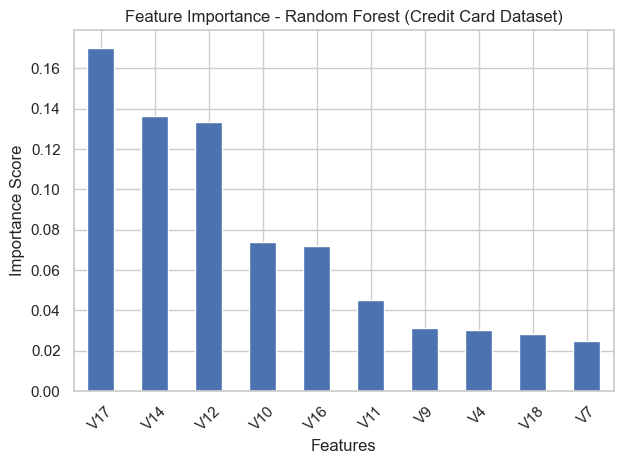

In [11]:

# Random Forest using SAME dataset


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1. Use your existing dataset (df)
# -----------------------------
import pandas as pd

# Load your dataset (update path if needed)
df = pd.read_csv("creditcard_final.csv")

# Quick check
print(df.head())
# Target = 'Class' (fraud)
X = df.drop('Class', axis=1)
y = df['Class']

# -----------------------------
# 2. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3. Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -----------------------------
# 4. Predictions
# -----------------------------
y_pred = rf_model.predict(X_test)

# -----------------------------
# 5. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# -----------------------------
# 6. Feature Importance (KEY GRAPH)
# -----------------------------
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest (Credit Card Dataset)")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

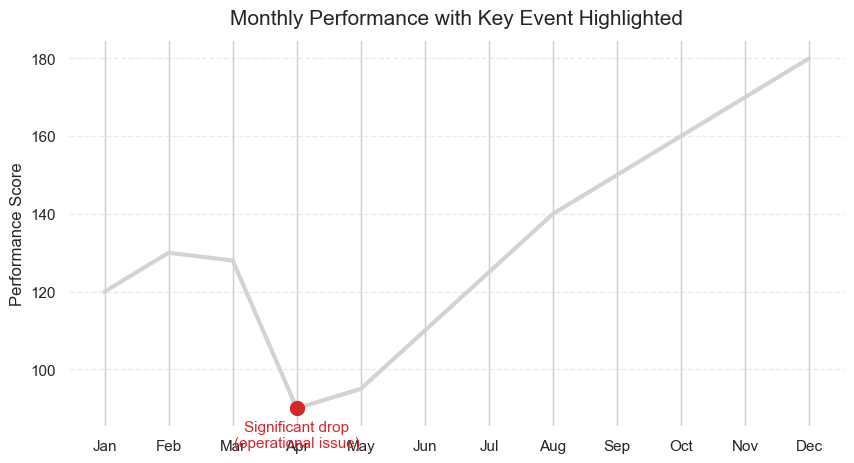

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fake monthly data to mimic a trend with a meaningful dip
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
values = [120, 130, 128, 90, 95, 110, 125, 140, 150, 160, 170, 180]

plt.figure(figsize=(10,5))

# Base line
plt.plot(months, values, color="lightgray", linewidth=3)

# Highlighted section (Apr dip)
highlight_idx = 3
plt.plot(months[highlight_idx], values[highlight_idx], 
         marker="o", markersize=10, color="#d62728")

# Label the point
plt.text(months[highlight_idx], values[highlight_idx] - 10,
         "Significant drop\n(operational issue)",
         color="#d62728", fontsize=11, ha="center")

# Title and labels
plt.title("Monthly Performance with Key Event Highlighted", fontsize=15, pad=12)
plt.ylabel("Performance Score")

# Minimal clutter (SWD style)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.box(False)

plt.show()
